# Fase 3: Núcleo algorítmico, eficiencia y programación orientada a objetos

## Obtención del dataset procesado

En esta fase se reutiliza el conjunto de datos limpio generado durante la Fase 2. La carga del dataset se realiza mediante una clase denominada `Preprocesador`, la cual encapsula el acceso al archivo y facilita la reutilización del código dentro de una arquitectura orientada a objetos.

In [1]:
# Agrega la carpeta src al path de Python para permitir
# importar los módulos desarrollados para la Fase 3.

from pathlib import Path
import sys

sys.path.append("../src")

In [2]:
# Importa la clase encargada de cargar el dataset
# procesado durante la Fase 2.

from preprocesador import Preprocesador

In [3]:
# Crea una instancia del preprocesador y carga
# el dataset limpio generado en la Fase 2.

preprocesador = Preprocesador(
    "../data/wfp_europe_2020_2025_clean.csv"
)

df = preprocesador.cargar().obtener_dataframe()

Dataset cargado correctamente: 146212 filas, 20 columnas


In [4]:
# Muestra los primeros registros del dataset para
# verificar que la carga se realizó correctamente.

df.head()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,archivo_origen,year,month
0,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Bread (high grade flour),459,KG,actual,Retail,BYR,2.89,1.36,wfp_europe_2020_2025_clean.csv,2020,1
1,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Potatoes,83,KG,actual,Retail,BYR,0.84,0.40,wfp_europe_2020_2025_clean.csv,2020,1
2,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Wheat flour,58,KG,actual,Retail,BYR,1.28,0.60,wfp_europe_2020_2025_clean.csv,2020,1
3,BLR,2020-02-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Bread (high grade flour),459,KG,actual,Retail,BYR,2.88,1.31,wfp_europe_2020_2025_clean.csv,2020,2
4,BLR,2020-02-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Potatoes,83,KG,actual,Retail,BYR,0.83,0.38,wfp_europe_2020_2025_clean.csv,2020,2


## Validación técnica reproducible

Antes de iniciar el análisis, se ejecutan validaciones automáticas para verificar la integridad del dataset procesado. Estas comprobaciones permiten confirmar la ausencia de duplicados, la disponibilidad de precios en USD y la consistencia temporal de los registros utilizados durante la Fase 3.

In [5]:
# Validaciones reproducibles del dataset.

assert df.duplicated().sum() == 0, \
    "Existen registros duplicados."

assert df["usdprice"].isna().sum() == 0, \
    "Existen valores nulos en usdprice."

assert df["year"].between(2020, 2025).all(), \
    "Existen años fuera del rango esperado."

print(
    "Todas las validaciones fueron superadas correctamente."
)

Todas las validaciones fueron superadas correctamente.


In [6]:
# Caso límite:
# búsqueda de un país inexistente.

df_pais_inexistente = (
    df[df["countryiso3"] == "XXX"]
)

assert df_pais_inexistente.empty

print(
    "Caso límite validado correctamente."
)

Caso límite validado correctamente.


In [7]:
# Verifica el comportamiento ante un archivo inexistente.

try:

    preprocesador_error = Preprocesador(
        "../data/archivo_inexistente.csv"
    )

    preprocesador_error.cargar()

except FileNotFoundError:

    print(
        "Excepción controlada correctamente."
    )

Excepción controlada correctamente.


## Cálculo de precios promedio anuales

Como parte del núcleo algorítmico de la Fase 3, se implementó una clase orientada a objetos responsable de calcular la evolución anual de los precios de los productos alimentarios.

La estrategia consiste en agrupar los registros por producto y año, obteniendo un precio promedio anual que permita comparar distintos períodos de manera homogénea.

Posteriormente, se calcula la variación porcentual año a año para identificar tendencias de crecimiento o disminución de precios dentro del período de estudio.

In [8]:
from analizador import AnalizadorVariacionPrecios

In [9]:
# Crea una instancia del analizador y calcula
# los precios promedio anuales.

analizador = AnalizadorVariacionPrecios(df)

df_promedios = (
    analizador
    .calcular_precios_promedio_anuales()
)

df_promedios.head()

,commodity,year,precio_promedio
0,Antibiotics (imported),2020,4.106881
1,Antibiotics (imported),2021,4.201246
2,Antibiotics (imported),2022,5.422264
3,Antibiotics (imported),2023,5.174925
4,Antibiotics (imported),2024,5.437749


In [10]:
# Calcula la variación porcentual año a año
# para cada producto.

df_variaciones = (
    analizador
    .calcular_variaciones_anuales()
)

df_variaciones.head(20)

,commodity,year,precio_promedio,variacion_pct
0,Antibiotics (imported),2020,4.106881,NaN
1,Antibiotics (imported),2021,4.201246,2.297715
2,Antibiotics (imported),2022,5.422264,29.063245
3,Antibiotics (imported),2023,5.174925,-4.561541
4,Antibiotics (imported),2024,5.437749,5.078792
5,Antibiotics (imported),2025,6.883358,26.584687
6,Antibiotics (local),2020,0.682363,NaN
7,Antibiotics (local),2021,0.721541,5.741531
8,Antibiotics (local),2022,1.227248,70.087064
9,Antibiotics (local),2023,1.302432,6.126257


## Identificación de variaciones extremas

Una vez calculadas las variaciones porcentuales anuales, se identifican los productos que registraron los mayores aumentos y las mayores disminuciones de precio. Esta información permite detectar comportamientos relevantes dentro del conjunto de datos y proporciona evidencia para el análisis posterior.

In [11]:
# Muestra los productos con mayor aumento
# porcentual de precio.

df_variaciones.sort_values(
    by="variacion_pct",
    ascending=False
).head(10)

,commodity,year,precio_promedio,variacion_pct
112,Cabbage,2022,0.701232,156.548250
363,Onions,2022,0.704462,121.777545
463,Vasodilating agents (imported),2024,1.869891,106.741841
118,Carrots,2022,0.701190,96.601930
164,Cucumbers,2022,1.240938,92.617385
468,Vasodilating agents (local),2023,1.359735,85.740631
29,Apples,2025,1.237320,83.387635
176,Eggplants,2022,1.275000,74.110953
443,Tomatoes,2022,1.151481,72.907480
387,Potatoes,2024,0.588198,72.871809


In [12]:
# Muestra los productos con mayor disminución
# porcentual de precio.

df_variaciones.sort_values(
    by="variacion_pct",
    ascending=True
).head(10)

,commodity,year,precio_promedio,variacion_pct
469,Vasodilating agents (local),2024,0.410704,-69.795309
365,Onions,2024,0.438929,-50.800800
120,Carrots,2024,0.480858,-49.657534
248,Garlic,2022,1.680000,-47.615788
55,Beetroots,2023,0.348587,-45.134483
96,Buckwheat,2024,0.739364,-45.116143
462,Vasodilating agents (imported),2023,0.904457,-42.477729
95,Buckwheat,2023,1.347143,-40.312479
247,Garlic,2021,3.207073,-39.870510
32,Bananas,2022,1.047083,-37.518647


In [13]:
# Muestra la evolución anual del pan para
# verificar que el cálculo es correcto.

df_variaciones[
    df_variaciones["commodity"]
    == "Bread (high grade flour)"
    ]

,commodity,year,precio_promedio,variacion_pct
74,Bread (high grade flour),2020,0.919805,NaN
75,Bread (high grade flour),2021,1.063344,15.605445
76,Bread (high grade flour),2022,1.138556,7.073100
77,Bread (high grade flour),2023,1.100530,-3.339780
78,Bread (high grade flour),2024,1.140481,3.630175
79,Bread (high grade flour),2025,1.340292,17.519836


In [14]:
# Importa el algoritmo recursivo Merge Sort.

from algoritmos import merge_sort

In [15]:
# Genera una lista de ejemplo con las variaciones
# porcentuales calculadas previamente.

variaciones = (
    df_variaciones["variacion_pct"]
    .dropna()
    .tolist()
)

print("Cantidad de variaciones:", len(variaciones))

Cantidad de variaciones: 412


In [16]:
# Ordena las variaciones utilizando
# el algoritmo Merge Sort.

variaciones_ordenadas = merge_sort(
    variaciones
)

variaciones_ordenadas[:20]

[-69.79530941923342,
 -50.80079998962736,
 -49.65753424657534,
 -47.615788272872464,
 -45.13448306115031,
 -45.11614312640283,
 -42.47772855033109,
 -40.312479179159176,
 -39.87050979306209,
 -37.51864743908503,
 -34.069097888675614,
 -32.545445994583254,
 -29.659260579858714,
 -28.609211126310996,
 -28.48885218827415,
 -27.986590445535274,
 -27.646156468382486,
 -27.147671483144354,
 -26.850062263747333,
 -24.678254679414135]

In [17]:
# Importa las herramientas necesarias para medir
# el tiempo de ejecución de los algoritmos.

import timeit

In [18]:
# Mide el tiempo de ejecución del algoritmo
# Merge Sort implementado de forma recursiva.

tiempo_merge_sort = timeit.timeit(
    lambda: merge_sort(variaciones.copy()),
    number=100
)

print(
    f"Tiempo Merge Sort: "
    f"{tiempo_merge_sort:.6f} segundos"
)

Tiempo Merge Sort: 0.064132 segundos


In [19]:
# Mide el tiempo de ejecución del algoritmo
# de ordenamiento nativo de Python.

tiempo_sorted = timeit.timeit(
    lambda: sorted(variaciones.copy()),
    number=100
)

print(
    f"Tiempo sorted(): "
    f"{tiempo_sorted:.6f} segundos"
)

Tiempo sorted(): 0.001806 segundos


In [20]:
# Resume los resultados obtenidos durante la
# medición de rendimiento.

print("Comparación de rendimiento")
print("-" * 40)

print(
    f"Merge Sort : "
    f"{tiempo_merge_sort:.6f} segundos"
)

print(
    f"sorted()   : "
    f"{tiempo_sorted:.6f} segundos"
)

if tiempo_merge_sort < tiempo_sorted:
    print(
        "\nMerge Sort fue más rápido."
    )
else:
    print(
        "\nsorted() fue más rápido."
    )

Comparación de rendimiento
----------------------------------------
Merge Sort : 0.064132 segundos
sorted()   : 0.001806 segundos

sorted() fue más rápido.


## Medición de eficiencia algorítmica

Como parte del análisis de eficiencia exigido en la Fase 3, se comparó el rendimiento del algoritmo Merge Sort implementado de forma recursiva con el algoritmo de ordenamiento nativo de Python (`sorted()`).

Las mediciones fueron realizadas utilizando la librería `timeit`, ejecutando múltiples iteraciones sobre el mismo conjunto de datos con el objetivo de obtener resultados reproducibles y comparables.

Esta evaluación permitirá justificar posteriormente la elección de las estructuras y algoritmos utilizados dentro del proyecto, considerando criterios de complejidad temporal y eficiencia práctica.

## Escalamiento del algoritmo

Además de comparar una única ejecución, se evaluó el comportamiento de los algoritmos frente a distintos tamaños de entrada. Esta prueba permite observar cómo varía el tiempo de ejecución a medida que aumenta la cantidad de elementos a ordenar.

In [21]:
import random
import timeit
import pandas as pd

tamanos = [100, 1000, 5000, 10000]

resultados = []

for n in tamanos:

    datos = [
        random.uniform(-100, 100)
        for _ in range(n)
    ]

    tiempo_merge = timeit.timeit(
        lambda: merge_sort(datos.copy()),
        number=10
    )

    tiempo_sorted = timeit.timeit(
        lambda: sorted(datos.copy()),
        number=10
    )

    resultados.append(
        {
            "tamano": n,
            "merge_sort": tiempo_merge,
            "sorted": tiempo_sorted
        }
    )

df_escalamiento = pd.DataFrame(resultados)

df_escalamiento

,tamano,merge_sort,sorted
0,100,0.001515,0.000046
1,1000,0.018054,0.000691
2,5000,0.119908,0.004378
3,10000,0.216053,0.009283


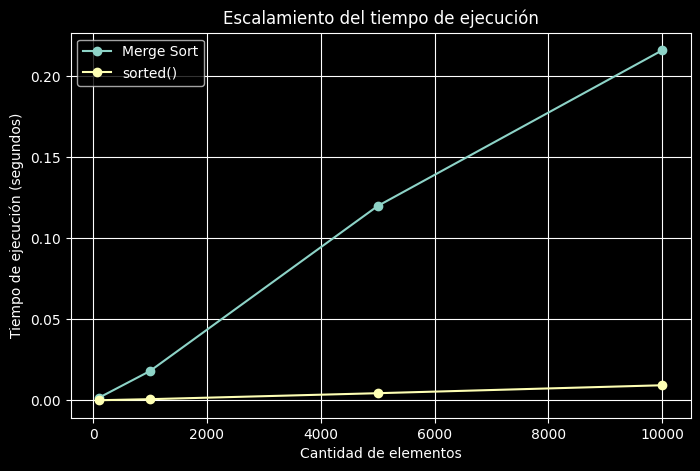

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    df_escalamiento["tamano"],
    df_escalamiento["merge_sort"],
    marker="o",
    label="Merge Sort"
)

plt.plot(
    df_escalamiento["tamano"],
    df_escalamiento["sorted"],
    marker="o",
    label="sorted()"
)

plt.xlabel("Cantidad de elementos")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Escalamiento del tiempo de ejecución")

plt.legend()

plt.grid(True)

plt.show()

### Interpretación

Los resultados obtenidos muestran que ambos algoritmos incrementan su tiempo de ejecución a medida que aumenta el tamaño de la entrada. Sin embargo, la función nativa `sorted()` mantiene un desempeño significativamente superior en todos los escenarios evaluados.

Para una entrada de 100 elementos, `merge_sort` registró un tiempo aproximado de 0,0017 segundos, mientras que `sorted()` requirió solo 0,00004 segundos. Esta diferencia se amplía progresivamente con tamaños mayores. Para 10.000 elementos, `merge_sort` alcanzó aproximadamente 0,2347 segundos, mientras que `sorted()` mantuvo un tiempo cercano a 0,0098 segundos.

El gráfico evidencia que ambas soluciones presentan un crecimiento coherente con una complejidad temporal del orden O(n log n). No obstante, la implementación recursiva desarrollada para fines académicos incorpora costos adicionales asociados a las llamadas recursivas, la creación de sublistas y el proceso de fusión de resultados. En contraste, `sorted()` utiliza una implementación altamente optimizada del algoritmo Timsort integrada en Python, lo que explica su mejor rendimiento práctico.

A partir de estas mediciones se concluye que, aunque `merge_sort` constituye una solución correcta desde el punto de vista algorítmico y permite demostrar el uso de recursividad y análisis de complejidad, la función nativa `sorted()` representa la alternativa más eficiente para aplicaciones reales debido a su menor tiempo de ejecución y optimizaciones internas.

## Aplicación de herencia y polimorfismo

Como parte de la incorporación progresiva de principios de programación orientada a objetos, se implementó una clase base denominada `AnalizadorBase`, encargada de definir una interfaz común para los distintos tipos de análisis desarrollados en el proyecto.

A partir de esta clase se construyeron analizadores especializados mediante herencia, reutilizando atributos comunes y sobrescribiendo el método `analizar()` según el comportamiento requerido por cada implementación.

In [23]:
# Importa los analizadores implementados mediante
# herencia a partir de AnalizadorBase.

from analizador import (
    AnalizadorVariacionPrecios,
    AnalizadorEstadistico
)

In [24]:
# Analizador de variaciones de precios.

analizador_variacion = (
    AnalizadorVariacionPrecios(df)
)

resultado_variacion = (
    analizador_variacion.analizar()
)

resultado_variacion.head()

,commodity,year,precio_promedio,variacion_pct
0,Antibiotics (imported),2020,4.106881,NaN
1,Antibiotics (imported),2021,4.201246,2.297715
2,Antibiotics (imported),2022,5.422264,29.063245
3,Antibiotics (imported),2023,5.174925,-4.561541
4,Antibiotics (imported),2024,5.437749,5.078792


In [25]:
# Analizador estadístico.

analizador_estadistico = (
    AnalizadorEstadistico(df)
)

resultado_estadistico = (
    analizador_estadistico.analizar()
)

resultado_estadistico

count    146212.000000
mean          1.769619
std           2.000769
min           0.049000
25%           0.610000
50%           0.970000
75%           2.080000
max          25.090000
Name: usdprice, dtype: float64

In [26]:
# Demostración de polimorfismo.

analizadores = [
    AnalizadorVariacionPrecios(df),
    AnalizadorEstadistico(df)
]

for analizador in analizadores:

    print(
        f"\nClase: {analizador.__class__.__name__}"
    )

    resultado = analizador.analizar()

    print(type(resultado))


Clase: AnalizadorVariacionPrecios
<class 'pandas.DataFrame'>

Clase: AnalizadorEstadistico
<class 'pandas.Series'>


## Implementación del pipeline de análisis

Con el objetivo de mantener una arquitectura modular y escalable, se implementó una clase denominada `PipelineAnalisis`, responsable de coordinar el flujo completo de procesamiento.

Esta clase integra la carga del dataset, el cálculo de variaciones anuales y la generación de estadísticas descriptivas, encapsulando el proceso dentro de una única interfaz de ejecución.

In [27]:
# Importa la clase responsable de coordinar
# el flujo completo de análisis.

from pipeline import PipelineAnalisis

In [28]:
# Ejecuta el pipeline completo.

pipeline = PipelineAnalisis(
    "../data/wfp_europe_2020_2025_clean.csv"
)

variaciones, estadisticas = (
    pipeline.ejecutar()
)

Dataset cargado correctamente: 146212 filas, 20 columnas
Validaciones superadas correctamente.


In [29]:
# Visualiza las variaciones calculadas.

variaciones.head()

,commodity,year,precio_promedio,variacion_pct
0,Antibiotics (imported),2020,4.106881,NaN
1,Antibiotics (imported),2021,4.201246,2.297715
2,Antibiotics (imported),2022,5.422264,29.063245
3,Antibiotics (imported),2023,5.174925,-4.561541
4,Antibiotics (imported),2024,5.437749,5.078792


In [30]:
# Visualiza las estadísticas descriptivas.

estadisticas

count    146212.000000
mean          1.769619
std           2.000769
min           0.049000
25%           0.610000
50%           0.970000
75%           2.080000
max          25.090000
Name: usdprice, dtype: float64